# Round 1 Price Analysis — INTARIAN_PEPPER_ROOT & ASH_COATED_OSMIUM

In [3]:
import csv
import matplotlib.pyplot as plt

BASE = '../imc-prosperity-4-backtester/prosperity4bt/resources/round1'
DAYS = ['-2', '-1', '0']

ipr_x, ipr_y = [], []
aco_x, aco_y = [], []
offset = 0

for day in DAYS:
    with open(f'{BASE}/prices_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            ts = offset + int(row['timestamp'])
            if row['product'] == 'INTARIAN_PEPPER_ROOT':
                ipr_x.append(ts); ipr_y.append(float(mid))
            elif row['product'] == 'ASH_COATED_OSMIUM':
                aco_x.append(ts); aco_y.append(float(mid))
    offset += 1_000_000

print(f'IPR ticks: {len(ipr_x)}  |  ACO ticks: {len(aco_x)}')
print(f'IPR range: {min(ipr_y):.1f} – {max(ipr_y):.1f}')
print(f'ACO range: {min(aco_y):.1f} – {max(aco_y):.1f}')

IPR ticks: 29946  |  ACO ticks: 29951
IPR range: 9998.5 – 13007.0
ACO range: 9977.0 – 10023.0


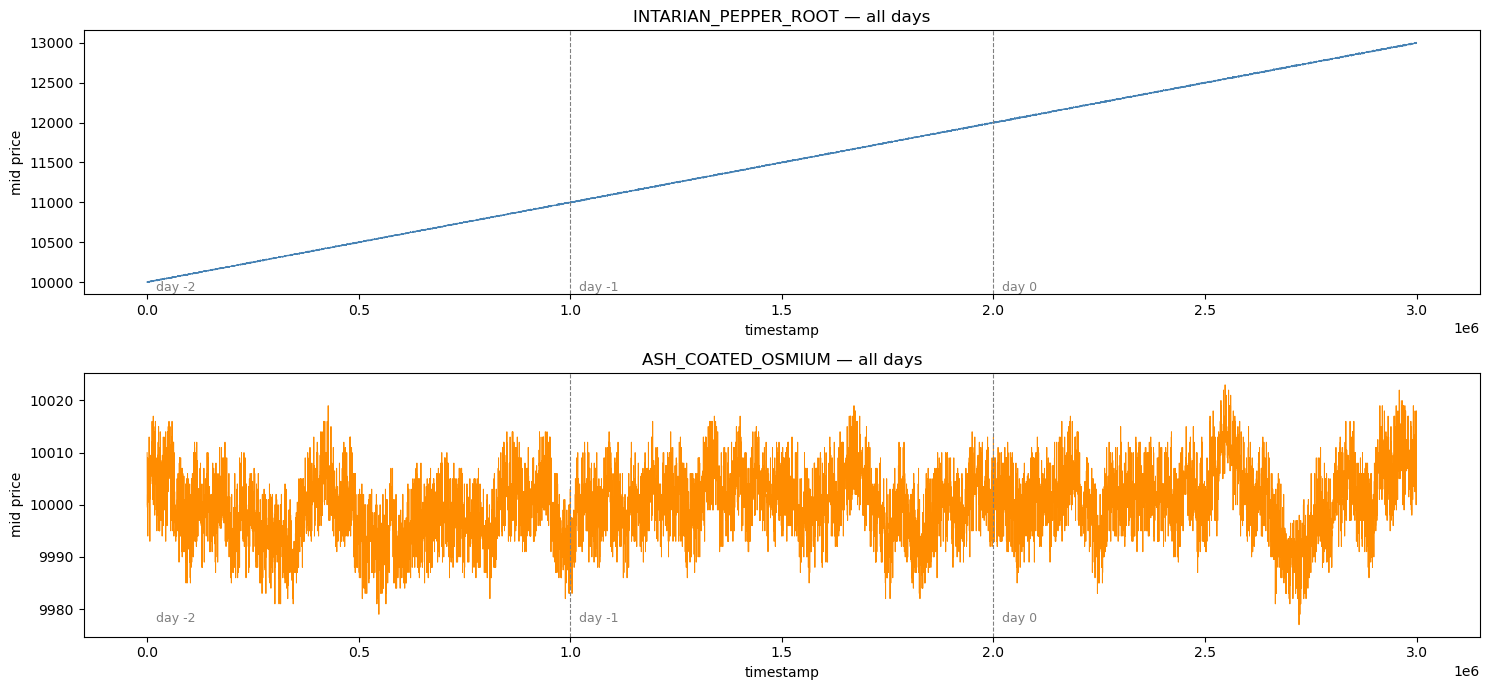

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=False)

ax1.plot(ipr_x, ipr_y, lw=0.7, color='steelblue')
ax1.set_title('INTARIAN_PEPPER_ROOT — all days')
ax1.set_ylabel('mid price')
ax1.set_xlabel('timestamp')
for sep in [1_000_000, 2_000_000]:
    ax1.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax1.text(i * 1_000_000 + 20_000, ax1.get_ylim()[0] if ax1.get_ylim()[0] != 0 else min(ipr_y),
             label, fontsize=9, color='gray', va='bottom')

ax2.plot(aco_x, aco_y, lw=0.7, color='darkorange')
ax2.set_title('ASH_COATED_OSMIUM — all days')
ax2.set_ylabel('mid price')
ax2.set_xlabel('timestamp')
for sep in [1_000_000, 2_000_000]:
    ax2.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax2.text(i * 1_000_000 + 20_000, min(aco_y), label, fontsize=9, color='gray', va='bottom')

plt.tight_layout()
plt.show()